In [1]:
import pandas as pd

df = pd.read_csv("lifesat.csv")
print(df.head(5))


   Country  GDP per capita (USD)  Life satisfaction
0   Russia          26456.387938                5.8
1   Greece          27287.083401                5.4
2   Turkey          28384.987785                5.5
3   Latvia          29932.493910                5.9
4  Hungary          31007.768407                5.6


In [2]:
# Basic info
print("=== Basic info ===")
print(df.info())

# Summary statistics (numeric columns)
print("\n=== Summary statistics (numeric) ===")
print(df.describe())


=== Basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes
None

=== Summary statistics (numeric) ===
       GDP per capita (USD)  Life satisfaction
count             27.000000          27.000000
mean           41564.521771           6.566667
std             9631.452319           0.765607
min            26456.387938           5.400000
25%            33938.289305           5.900000
50%            41627.129269           6.800000
75%            49690.580269           7.300000
max            60235.728492           7.600000


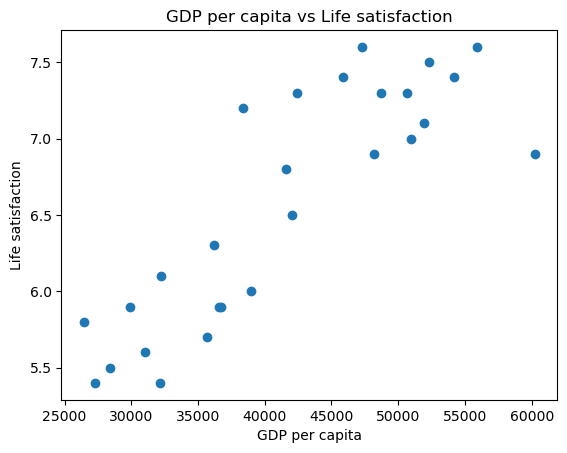

In [8]:
# Create scatter plot
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(df["GDP per capita (USD)"], df["Life satisfaction"])

# Labels and title
plt.xlabel("GDP per сapita")
plt.ylabel("Life satisfaction")
plt.title("GDP per сapita vs Life satisfaction")

plt.show()

In [ ]:
The scatter plot shows a clear positive relationship between GDP per capita and life satisfaction. 
Countries with higher income levels tend to report higher levels of life satisfaction. 
However, the relationship is not perfectly linear, suggesting that other social and economic factors also influence well-being.

In [9]:
# Input (X) and target (y)
X = df[["GDP per capita (USD)"]].values   # 2D array
y = df["Life satisfaction"].values        # 1D array

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27, 1)
y shape: (27,)


In [10]:
from sklearn.linear_model import LinearRegression
#Train model
model = LinearRegression()
model.fit(X, y)

# Display coefficient and intercept
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (slope): 6.778899694341222e-05
Intercept: 3.7490494273769093


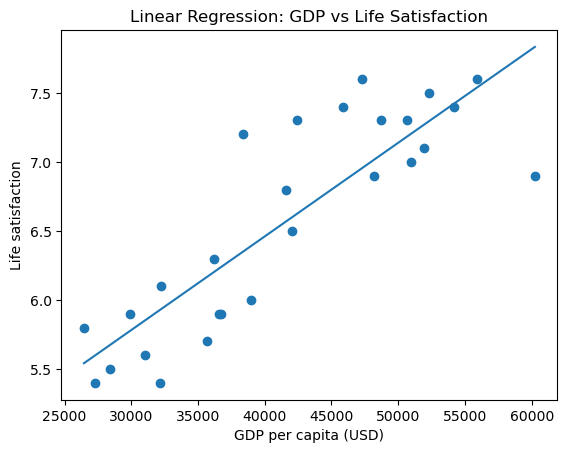

In [13]:
import numpy as np
import matplotlib.pyplot as plt

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred_line = model.predict(X_range)

plt.figure()
plt.scatter(X, y)
plt.plot(X_range, y_pred_line)

plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life satisfaction")
plt.title("Linear Regression: GDP vs Life Satisfaction")
plt.show()

In [14]:
# Predict life satisfaction for GDP = 37,655.2 USD

new_gdp = 37655.2
predicted_value = model.predict([[new_gdp]])

print(f"Predicted Life Satisfaction for GDP {new_gdp} USD: {predicted_value[0]:.3f}")


Predicted Life Satisfaction for GDP 37655.2 USD: 6.302


In [ ]:
The predicted life satisfaction for a GDP of 37,655.2 USD is 6.302.

This value falls within the overall range of life satisfaction in the dataset (approximately 5.4 to 7.6), which makes the prediction reasonable. 
Since the GDP value is within the range of the training data, this is an interpolation, meaning the prediction is relatively reliable.

The result is consistent with the positive linear relationship observed earlier: 
as GDP per capita increases, life satisfaction tends to increase. 
A GDP of around 37,655 USD corresponds to a moderate-to-high level of life satisfaction according to the model.

In [15]:
from sklearn.neighbors import KNeighborsRegressor

# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X, y)


KNeighborsRegressor(n_neighbors=3)

In [16]:
gdp_value = 37655.2

# KNN prediction
knn_prediction = knn_model.predict([[gdp_value]])[0]

# Linear Regression prediction (already trained before)
linear_prediction = model.predict([[gdp_value]])[0]

print("Linear Regression prediction:", round(linear_prediction, 3))
print("KNN (k=3) prediction:", round(knn_prediction, 3))


Linear Regression prediction: 6.302
KNN (k=3) prediction: 6.333


k = 1, Predicted Life Satisfaction = 7.2
k = 3, Predicted Life Satisfaction = 6.333
k = 5, Predicted Life Satisfaction = 6.26
k = 10, Predicted Life Satisfaction = 6.37


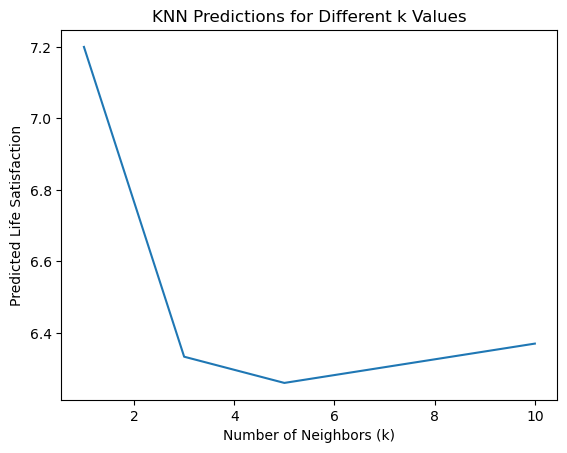

In [17]:
import matplotlib.pyplot as plt

neighbors = [1, 3, 5, 10]
predictions = []

for k in neighbors:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X, y)
    pred = knn.predict([[gdp_value]])[0]
    predictions.append(pred)
    print(f"k = {k}, Predicted Life Satisfaction = {round(pred, 3)}")

# Plot results
plt.figure()
plt.plot(neighbors, predictions)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Predicted Life Satisfaction")
plt.title("KNN Predictions for Different k Values")
plt.show()
